In [2]:
# Install with:
# pip install -r requirements.txt

In [1]:
!pip install -q -U keras-tuner
!pip -q -U install tensorboard

# Otimização de hiperparâmetros com Keras Tuner

Nos notebooks anteriores, todas as decisões relacionadas à arquitetura da rede neural foram definidas manualmente. Escolhemos o número de filtros, o número de neurônios, as taxas de *Dropout* e outros hiperparâmetros com base em conhecimento prévio e experimentação.

Embora essa abordagem seja adequada para modelos simples, ela apresenta uma limitação importante: **o número de combinações possíveis cresce rapidamente à medida que a arquitetura se torna mais complexa**.

Neste notebook utilizaremos o **Keras Tuner**, uma biblioteca desenvolvida para automatizar o processo de busca pelos melhores hiperparâmetros de um modelo de Deep Learning.

Em vez de construir uma única rede neural, o Keras Tuner treina e avalia diversas arquiteturas diferentes, comparando seu desempenho sobre o conjunto de validação e selecionando automaticamente aquela que apresenta os melhores resultados.

O pipeline geral permanece o mesmo:

```
Carregar dados
      ↓
Definir espaço de busca
      ↓
Executar o Keras Tuner
      ↓
Treinar o melhor modelo
      ↓
   Avaliar
      ↓
   Predizer
```

A diferença fundamental é que, agora, a arquitetura da rede deixa de ser definida manualmente e passa a ser otimizada automaticamente.

## Carregar dados

In [1]:
import os
import tensorboard
import numpy as np
import pandas as pd
import tensorflow as tf
import keras_tuner as kt
from pathlib import Path
from tensorflow import keras
import matplotlib.pyplot as plt

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

IMAGES_DIR = Path("./images")
IMAGES_DIR.mkdir(exist_ok=True)

I0000 00:00:1782757369.587544    4373 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782757405.597456    4373 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
mnist = keras.datasets.mnist

I0000 00:00:1782732161.845741    4699 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782732181.236527    4699 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [4]:
mnist

<module 'keras.datasets.mnist' from '/home/rusch/anaconda3/lib/python3.13/site-packages/keras/datasets/mnist/__init__.py'>

In [5]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [6]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [7]:
type(x_train[0])

numpy.ndarray

In [8]:
x_train.shape

(60000, 28, 28)

In [9]:
x_train[0][0].shape

(28,)

In [10]:
y_train.shape

(60000,)

In [11]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [12]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [13]:
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))

In [14]:
contagem = tuple(zip(*np.unique(y_train, return_counts=True)))
contagem

((np.uint8(0), np.int64(5923)),
 (np.uint8(1), np.int64(6742)),
 (np.uint8(2), np.int64(5958)),
 (np.uint8(3), np.int64(6131)),
 (np.uint8(4), np.int64(5842)),
 (np.uint8(5), np.int64(5421)),
 (np.uint8(6), np.int64(5918)),
 (np.uint8(7), np.int64(6265)),
 (np.uint8(8), np.int64(5851)),
 (np.uint8(9), np.int64(5949)))

In [15]:
for par in contagem:
    print(f"{par[0]}: {par[1] / len(y_train) * 100:.2f}%")

0: 9.87%
1: 11.24%
2: 9.93%
3: 10.22%
4: 9.74%
5: 9.04%
6: 9.86%
7: 10.44%
8: 9.75%
9: 9.92%


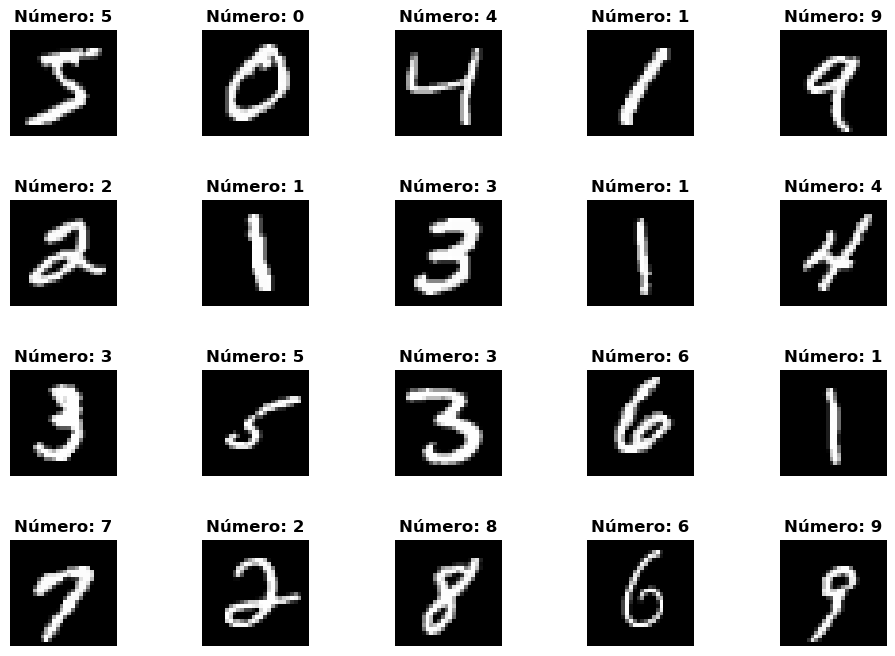

In [16]:
fig, axs = plt.subplots(4, 5, figsize=(12, 8))

for i, ax in enumerate(axs.flat):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(f"Número: {y_train[i]}", fontweight="bold")
    ax.axis("off")

fig.subplots_adjust(hspace=0.6)

plt.show()

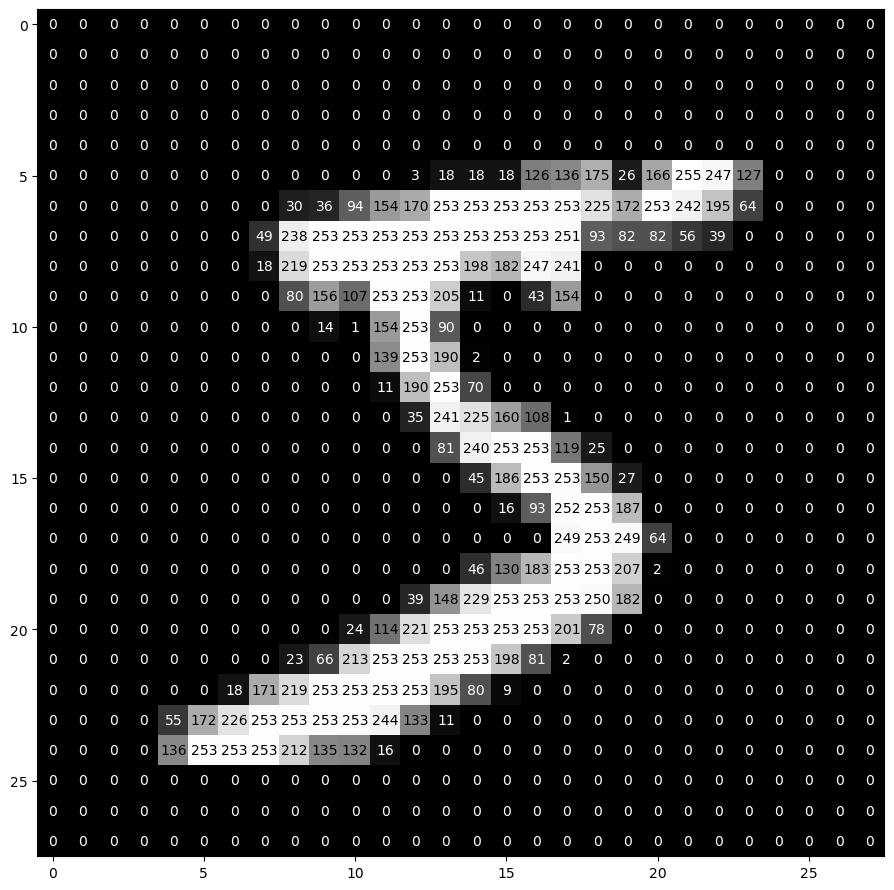

In [17]:
fig, ax = plt.subplots(figsize=(11, 11))

ax.imshow(x_train[0], cmap="gray")

for linha in range(28):
    for coluna in range(28):
        valor = x_train[0][linha][coluna]
        ax.annotate(
            str(valor),
            xy=(coluna, linha),
            color="black" if valor > 100 else "white",
            horizontalalignment="center",
            verticalalignment="center",
        )

plt.show()

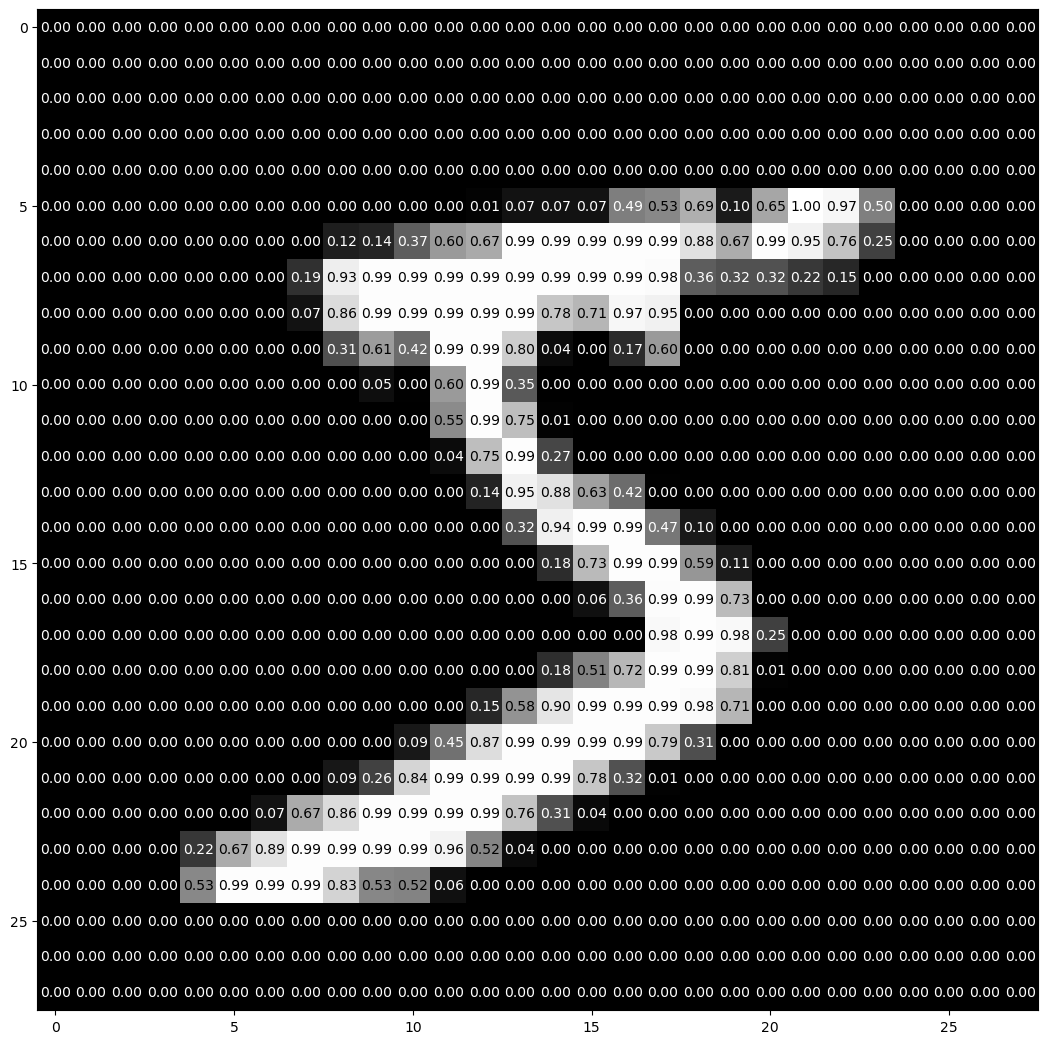

In [18]:
fig, ax = plt.subplots(figsize=(13, 13))

ax.imshow(x_train[0] / 255, cmap="gray")

for linha in range(28):
    for coluna in range(28):
        valor = x_train[0][linha][coluna] / 255
        ax.annotate(
            f"{valor:.2f}",
            xy=(coluna, linha),
            color="black" if valor > 0.5 else "white",
            horizontalalignment="center",
            verticalalignment="center",
        )

plt.show()

## Definir função Tuner

# Definir o espaço de busca dos hiperparâmetros

Antes de iniciar a otimização, é necessário informar ao Keras Tuner **quais hiperparâmetros poderão ser modificados** durante a busca.

Em vez de definir valores fixos para a arquitetura da rede neural, especificaremos intervalos ou conjuntos de valores possíveis.

Esses conjuntos de valores constituem o chamado **espaço de busca (Search Space)**.

A partir dele, o Keras Tuner construirá automaticamente diferentes arquiteturas, treinando e avaliando cada uma delas até identificar aquela que apresenta o melhor desempenho.

`pip install -q -U keras-tuner`

https://www.tensorflow.org/tutorials/keras/keras_tuner

https://keras.io/api/keras_tuner/tuners/

## Definindo a função `model_builder(hp)`

A função `model_builder(hp)` é o componente central do processo de otimização com o **Keras Tuner**.

Nos modelos anteriores, a arquitetura da rede neural era definida manualmente: escolhíamos diretamente o número de filtros, a taxa de aprendizado e demais configurações. Neste notebook, parte dessas escolhas passa a ser feita automaticamente pelo Keras Tuner.

O argumento `hp` representa o objeto de **hiperparâmetros**. Ele permite definir quais valores poderão ser testados durante a busca. Assim, em vez de fixar uma única arquitetura, construímos uma função capaz de gerar várias arquiteturas possíveis.

Em termos práticos, a função `model_builder(hp)` funciona como uma “fábrica de modelos”: a cada tentativa, o Keras Tuner chama essa função, escolhe uma combinação diferente de hiperparâmetros, constrói um modelo, treina esse modelo e compara seu desempenho com os demais.

In [19]:
def model_builder(hp):
    model = keras.models.Sequential()
    
    model.add(keras.layers.InputLayer(input_shape=(28, 28, 1)))
    model.add(keras.layers.Rescaling(scale=1./255))
    
    model.add(keras.layers.RandomRotation(0.1))
    model.add(keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1))
    model.add(keras.layers.RandomZoom(0.1))
    
    model.add(keras.layers.Conv2D(
        hp.Int("conv_1_filters",  min_value=16, max_value=64, step=2, sampling="log"), 
        (3, 3),  
        activation="relu"))
    model.add(keras.layers.MaxPooling2D())
    model.add(keras.layers.Dropout(0.2))
    
    model.add(keras.layers.Conv2D(
        hp.Int("conv_2_filters",  min_value=32, max_value=128, step=2, sampling="log"), 
        (3, 3),  
        activation="relu"))
    model.add(keras.layers.MaxPooling2D())
    model.add(keras.layers.Dropout(0.2))
    
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(10, activation="softmax"))


    optimizer = keras.optimizers.Adam(learning_rate=hp.Choice("learning_rate", values=[1E-2, 1E-3, 1E-4]))
    loss = keras.losses.SparseCategoricalCrossentropy()
    metric = keras.metrics.SparseCategoricalAccuracy()
    
    model.compile(optimizer=optimizer, loss=loss, metrics=[metric])

    return model

### Inicialização do modelo

A arquitetura é definida utilizando `keras.models.Sequential()`, que permite construir a rede neural como uma sequência linear de camadas.

Esse tipo de estrutura é adequado para este problema porque o fluxo de informação segue uma ordem bem definida: $\text{Imagem} \rightarrow \text{Pré-processamento} \rightarrow \text{Convoluções} \rightarrow \text{Classificação}$

Cada camada recebe como entrada a saída da camada anterior, até que a última camada produza as probabilidades associadas aos dez dígitos possíveis.

### Camada de entrada e normalização

A primeira camada define o formato das imagens de entrada: $28 \times 28 \times 1$

Isso significa que cada imagem possui 28 pixels de altura, 28 pixels de largura e apenas um canal de cor, pois a base MNIST está em escala de cinza.

Em seguida, a camada `Rescaling(scale=1./255)` normaliza os valores dos pixels, convertendo-os do intervalo original: $[0,255]$, para o intervalo: $[0,1]$

Essa normalização é importante porque melhora a estabilidade numérica do treinamento e facilita o processo de otimização dos pesos da rede neural.

### Data Augmentation dentro da arquitetura

As camadas `RandomRotation`, `RandomTranslation` e `RandomZoom` aplicam transformações aleatórias às imagens durante o treinamento.

Essas transformações aumentam artificialmente a diversidade dos dados apresentados à rede neural:

- `RandomRotation(0.1)` aplica pequenas rotações aos dígitos;
- `RandomTranslation(height_factor=0.1, width_factor=0.1)` desloca as imagens horizontalmente e verticalmente;
- `RandomZoom(0.1)` aplica pequenas variações de escala.

O objetivo é tornar o modelo mais robusto a variações naturais da escrita manual. Em vez de aprender apenas os dígitos exatamente como aparecem na base original, a rede passa a aprender versões levemente modificadas desses mesmos dígitos.

É importante destacar que essas transformações são aplicadas durante o treinamento. Na avaliação e na predição, o modelo utiliza as imagens originais.

### Primeira camada convolucional otimizada

A primeira camada convolucional é responsável por extrair padrões locais simples das imagens, como bordas, curvas e pequenos segmentos dos dígitos.

Nesta etapa, o número de filtros não é definido manualmente. Em vez disso, ele é escolhido pelo Keras Tuner por meio do hiperparâmetro:

```python
hp.Int("conv_1_filters", min_value=16, max_value=64, step=2, sampling="log")
```

Isso significa que o algoritmo testará diferentes quantidades de filtros entre $16$ e $64$, buscando a configuração que produza melhor desempenho no conjunto de validação.

A função de ativação utilizada é a **ReLU**, definida por: $f(x) = \max(0,x)$

Ela introduz não linearidade no modelo e permite que a rede aprenda padrões mais complexos.

### Segunda camada convolucional otimizada

A segunda camada convolucional aprende padrões mais abstratos a partir das características extraídas pela primeira camada.

Enquanto a primeira convolução tende a detectar estruturas simples, a segunda pode combinar essas informações para representar formas mais complexas, como curvas fechadas, inclinações e combinações típicas dos dígitos manuscritos.

Novamente, o número de filtros é escolhido automaticamente pelo Keras Tuner:

```python
hp.Int("conv_2_filters", min_value=32, max_value=128, step=2, sampling="log")
```

Neste caso, o espaço de busca varia entre $32$ e $128$ filtros. Isso permite que o algoritmo teste arquiteturas com diferentes capacidades de representação.

### Camada de classificação

Após os blocos convolucionais, a camada `Flatten` transforma os mapas de características em um vetor unidimensional.

Esse vetor contém as informações extraídas pelas convoluções e será utilizado pela camada final `Dense`.

A última camada possui 10 neurônios, um para cada classe da base MNIST: $0,1,2,\ldots,9$

A função de ativação utilizada é a **Softmax**, que transforma as saídas da rede em uma distribuição de probabilidades.

Assim, o modelo não retorna apenas uma classe, mas uma probabilidade associada a cada dígito. A classe final prevista corresponde ao neurônio com maior probabilidade.

### Compilação do modelo dentro da função

Além de construir a arquitetura, a função `model_builder(hp)` também compila o modelo.

O otimizador escolhido é o **Adam**, mas sua taxa de aprendizado não é fixa. Ela também é tratada como hiperparâmetro:

```python
hp.Choice("learning_rate", values=[1E-2, 1E-3, 1E-4])
```

Isso significa que o Keras Tuner testará três valores possíveis: $10^{-2}, 10^{-3}, 10^{-4}$.

A função de perda utilizada é a `SparseCategoricalCrossentropy`, adequada para problemas de classificação multiclasse quando os rótulos são inteiros, como ocorre na base MNIST.

A métrica utilizada é a `SparseCategoricalAccuracy`, que mede a proporção de imagens classificadas corretamente.

Ao final, a função retorna um modelo Keras completo, já construído e compilado, pronto para ser treinado pelo Keras Tuner.

## Configurando o algoritmo de busca

Após definir o espaço de busca, criamos o objeto responsável por conduzir a otimização dos hiperparâmetros.

O Keras Tuner oferece diferentes estratégias de busca, como:

- Random Search;
- Hyperband;
- Bayesian Optimization.

Neste projeto utilizaremos o algoritmo escolhido no código, que explorará automaticamente diferentes combinações de hiperparâmetros e comparará o desempenho obtido por cada arquitetura no conjunto de validação.

In [20]:
tuner = kt.Hyperband(
    model_builder,
    objective="val_loss",
    max_epochs=10,
    factor=3,
    directory="tuner",
    project_name="mnist",
)

Reloading Tuner from tuner/mnist/tuner0.json


## Fit modelo Keras

# Etapa 3 — Executando a busca pelos melhores hiperparâmetros

Nesta etapa inicia-se o processo de otimização propriamente dito.

Para cada combinação de hiperparâmetros:

1. uma nova rede neural é construída;
2. essa rede é treinada;
3. seu desempenho é avaliado utilizando o conjunto de validação;
4. o resultado é armazenado pelo Keras Tuner.

Esse procedimento é repetido diversas vezes até que seja encontrada a arquitetura com melhor desempenho segundo a métrica definida pelo usuário.

In [21]:
early_stop = keras.callbacks.EarlyStopping(
    patience=5,
    verbose=1,
    min_delta=1E-4,
)

tuner.search(
    x_train,
    y_train,
    batch_size=512,
    validation_split=0.2,
    callbacks=[early_stop],
)

Trial 26 Complete [00h 09m 43s]
val_loss: 0.16349877417087555

Best val_loss So Far: 0.04963451623916626
Total elapsed time: 18h 48m 50s


Ao término da busca, o Keras Tuner possui um histórico contendo todas as arquiteturas avaliadas e o desempenho obtido por cada uma delas.

Em vez de selecionar manualmente uma configuração, o algoritmo identifica automaticamente aquela que apresentou os melhores resultados no conjunto de validação.

Essa abordagem reduz o caráter empírico da escolha dos hiperparâmetros e torna o processo de desenvolvimento mais sistemático e reproduzível.

## Recuperando os melhores hiperparâmetros

Concluída a etapa de otimização, recuperamos a melhor combinação de hiperparâmetros encontrada pelo algoritmo.

Esse conjunto representa a configuração que apresentou o melhor desempenho durante a busca e será utilizado para construir o modelo definitivo.

In [22]:
best_hps = tuner.get_best_hyperparameters()[0]

In [23]:
best_hps.values

{'conv_1_filters': 32,
 'conv_2_filters': 64,
 'learning_rate': 0.01,
 'tuner/epochs': 10,
 'tuner/initial_epoch': 4,
 'tuner/bracket': 1,
 'tuner/round': 1,
 'tuner/trial_id': '0016'}

### Interpretação dos melhores hiperparâmetros

O Keras Tuner identificou a seguinte configuração como a melhor combinação entre as arquiteturas avaliadas:

| Hiperparâmetro | Valor selecionado |
|---|---:|
| `conv_1_filters` | 32 |
| `conv_2_filters` | 64 |
| `learning_rate` | 0.01 |

Isso significa que, dentre as combinações testadas, o melhor desempenho no conjunto de validação foi obtido com uma primeira camada convolucional contendo 32 filtros, uma segunda camada convolucional contendo 64 filtros e uma taxa de aprendizado igual a $10^{-2}$.

A escolha de $32$ e $64$ filtros indica uma arquitetura intermediária: suficientemente expressiva para aprender padrões relevantes dos dígitos, mas sem tornar o modelo excessivamente grande.

A taxa de aprendizado igual a $0.01$ indica que, neste experimento, o otimizador Adam conseguiu convergir adequadamente com passos relativamente maiores durante a atualização dos pesos.

# Etapa 4 — Treinando o melhor modelo

Após identificar a melhor arquitetura, realizamos um novo treinamento utilizando essa configuração.

Esse treinamento corresponde ao modelo definitivo, que será posteriormente avaliado e utilizado para realizar predições sobre novas imagens.

In [24]:
model = tuner.hypermodel.build(best_hps)

history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=512,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 44s 414ms/step - loss: 0.7664 - sparse_categorical_accuracy: 0.7519 - val_loss: 0.1061 - val_sparse_categorical_accuracy: 0.9688
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 38s 403ms/step - loss: 0.3156 - sparse_categorical_accuracy: 0.9024 - val_loss: 0.0810 - val_sparse_categorical_accuracy: 0.9758
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 38s 406ms/step - loss: 0.2458 - sparse_categorical_accuracy: 0.9254 - val_loss: 0.0663 - val_sparse_categorical_accuracy: 0.9800
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 38s 405ms/step - loss: 0.2072 - sparse_categorical_accuracy: 0.9357 - val_loss: 0.0654 - val_sparse_categorical_accuracy: 0.9797
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 38s 401ms/step - loss: 0.1899 - sparse_categorical_accuracy: 0.9413 - val_loss: 0.0676 - val_sparse_categorical_accuracy: 0.9785
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 38s 401ms/step - loss: 0.1715 - sparse_categorical_accuracy: 0.9474 - val_loss: 0.0710 - val_sparse_categorical_accuracy: 0.978

In [38]:
model.save("models/model_tuner_best_hps.keras")

In [ ]:
history_df = pd.DataFrame(history.history)
history_df.to_csv("../models/history_tuner.csv", index=False)

## Evaluate modelo Keras

In [25]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0744 - sparse_categorical_accuracy: 0.9790


[0.07436339557170868, 0.9789999723434448]

In [39]:
loaded_model = keras.models.load_model("models/model_tuner_best_hps.keras")

In [40]:
loaded_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_1            │ (None, 28, 28, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,480 (408.13 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 69,654 (272.09 KB)

In [41]:
loaded_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0744 - sparse_categorical_accuracy: 0.9790


[0.07436339557170868, 0.9789999723434448]

### Interpretação do resultado de avaliação

A avaliação do modelo no conjunto de teste retornou os seguintes valores:

| Métrica | Valor |
|---|---:|
| **Loss** | 0,0744 |
| **Accuracy** | 97,90% |

A função `model.evaluate(x_test, y_test)` utiliza imagens que não foram usadas para ajustar os pesos do modelo. Portanto, esse resultado mede a capacidade de generalização da rede neural.

A **loss de aproximadamente 0,0744** indica que o erro médio das previsões no conjunto de teste é baixo. Como a função de perda utilizada foi a `SparseCategoricalCrossentropy`, esse valor está relacionado à confiança do modelo na classe correta: quanto menor a loss, mais próximas as distribuições previstas estão dos rótulos verdadeiros.

A **acurácia de 97,90%** significa que o modelo classificou corretamente aproximadamente: $0,9790 \times 10000 = 9790$, imagens do conjunto de teste.

Consequentemente, cerca de $210$ imagens foram classificadas incorretamente.

Esse resultado indica que o modelo otimizado pelo Keras Tuner apresenta excelente desempenho na tarefa de reconhecimento de dígitos manuscritos. Embora a acurácia não tenha atingido $100\%$, o desempenho obtido é bastante elevado e confirma que a arquitetura selecionada aprendeu padrões representativos da base MNIST.

## Predict modelo Keras

## Curva da função de perda

A curva da função de perda permite acompanhar a evolução do erro do modelo ao longo das épocas de treinamento.

Neste gráfico, comparamos:

- `loss`: perda calculada no conjunto de treinamento;
- `val_loss`: perda calculada no conjunto de validação.

Essa comparação é importante porque permite verificar se o modelo está aprendendo padrões gerais ou se está apenas se ajustando excessivamente aos dados de treinamento.

TypeError: Figure.savefig() takes 2 positional arguments but 3 were given

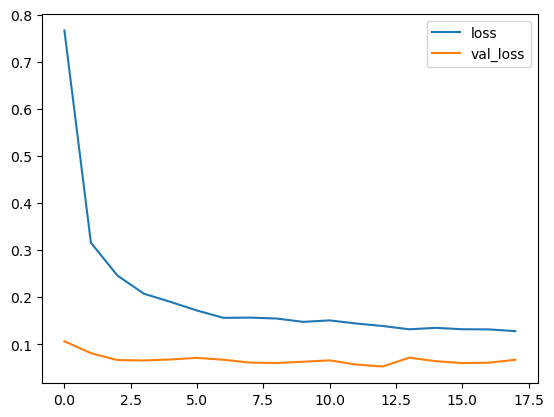

In [57]:
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.savefig(IMAGES_DIR / "loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

A curva de perda mostra uma queda acentuada nas primeiras épocas, indicando que o modelo aprende rapidamente padrões relevantes dos dígitos manuscritos.

Ao longo do treinamento, a `loss` continua diminuindo de forma gradual, enquanto a `val_loss` permanece em valores baixos, mas apresenta pequenas oscilações.

Um ponto importante é que a perda de treinamento pode permanecer acima da perda de validação neste tipo de arquitetura. Isso ocorre porque, durante o treinamento, o modelo é exposto a imagens artificialmente modificadas pelas camadas de **Data Augmentation** e também sofre o efeito do **Dropout**, que desativa aleatoriamente parte das ativações.

Na validação, por outro lado, as imagens são avaliadas sem essas perturbações. Assim, a tarefa pode se tornar relativamente mais fácil, resultando em uma perda de validação menor.

Portanto, essa diferença não deve ser interpretada automaticamente como erro ou overfitting. Ela reflete o efeito das técnicas de regularização utilizadas durante o treinamento.

As oscilações observadas na `val_loss` indicam que o modelo já se aproxima de uma região de estabilização, na qual novos treinamentos tendem a produzir ganhos menores.

## Curva da acurácia

A curva da acurácia mostra como a taxa de classificações corretas evolui ao longo do treinamento.

Neste gráfico, comparamos:

- `accuracy`: acurácia obtida no conjunto de treinamento;
- `val_accuracy`: acurácia obtida no conjunto de validação.

Enquanto a loss mede o erro associado às probabilidades previstas, a acurácia mede diretamente a proporção de dígitos classificados corretamente.

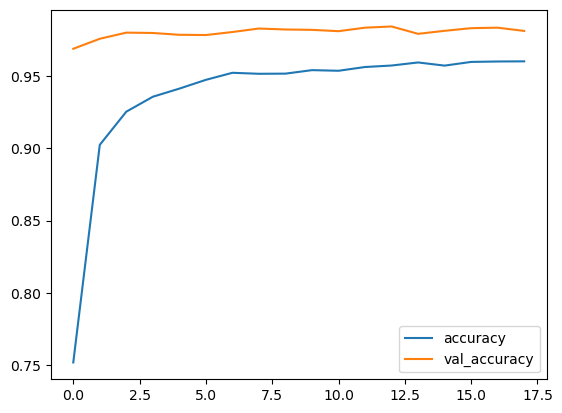

In [51]:
plt.plot(history.history["sparse_categorical_accuracy"], label="accuracy")
plt.plot(history.history["val_sparse_categorical_accuracy"], label="val_accuracy")
plt.legend()
plt.savefig(IMAGES_DIR / "accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

A curva de acurácia apresenta crescimento rápido nas primeiras épocas, mostrando que a rede neural aprende rapidamente a reconhecer os principais padrões da base MNIST.

Depois das primeiras épocas, o crescimento torna-se mais gradual, indicando que o modelo entra em uma fase de refinamento. Nessa etapa, os ganhos adicionais passam a ser menores, pois a rede já aprendeu grande parte da estrutura relevante dos dados.

Assim como observado na função de perda, a acurácia de validação pode permanecer acima da acurácia de treinamento. Isso ocorre porque, durante o treinamento, o modelo recebe imagens modificadas por **RandomRotation**, **RandomTranslation** e **RandomZoom**, além de operar com **Dropout** ativo.

Durante a validação, essas perturbações não são aplicadas. O modelo é avaliado sobre imagens originais e com toda a rede disponível, o que pode resultar em desempenho superior.

O resultado final no conjunto de teste, com acurácia de $\textbf{97,90\%}$, confirma que o modelo apresenta boa capacidade de generalização, classificando corretamente a grande maioria das imagens inéditas.

In [44]:
x_test[0].shape

(28, 28)

In [45]:
np.expand_dims(x_test[0], axis=0).shape

(1, 28, 28)

## Predição em uma imagem do conjunto de teste

Após o treinamento e a avaliação quantitativa, podemos analisar como o modelo realiza uma predição individual.

A função `model.predict()` retorna um vetor com 10 valores, correspondentes às probabilidades atribuídas a cada classe possível.

A classe prevista é aquela com maior probabilidade, obtida por:

```python
pred.argmax()
```

Essa análise é útil porque permite observar não apenas qual classe foi escolhida pelo modelo, mas também o grau de confiança associado à decisão.

In [46]:
model.predict(np.expand_dims(x_test[0], axis=0))[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


array([1.1040369e-10, 3.8343413e-07, 2.6943793e-03, 1.4715482e-07,
       1.7556440e-12, 1.3556082e-13, 3.1813647e-20, 9.9730515e-01,
       1.4276294e-10, 9.6088772e-09], dtype=float32)

A saída do modelo é um vetor de probabilidades contendo uma posição para cada dígito de $0$ a $9$.

No exemplo analisado, a maior probabilidade está associada ao dígito $\textbf{7}$, com confiança muito elevada. Isso indica que o modelo reconheceu corretamente o padrão visual da imagem e atribuiu baixa probabilidade às demais classes.

Esse tipo de saída é mais informativo do que uma classificação direta, pois permite avaliar o nível de segurança da rede neural em sua decisão.

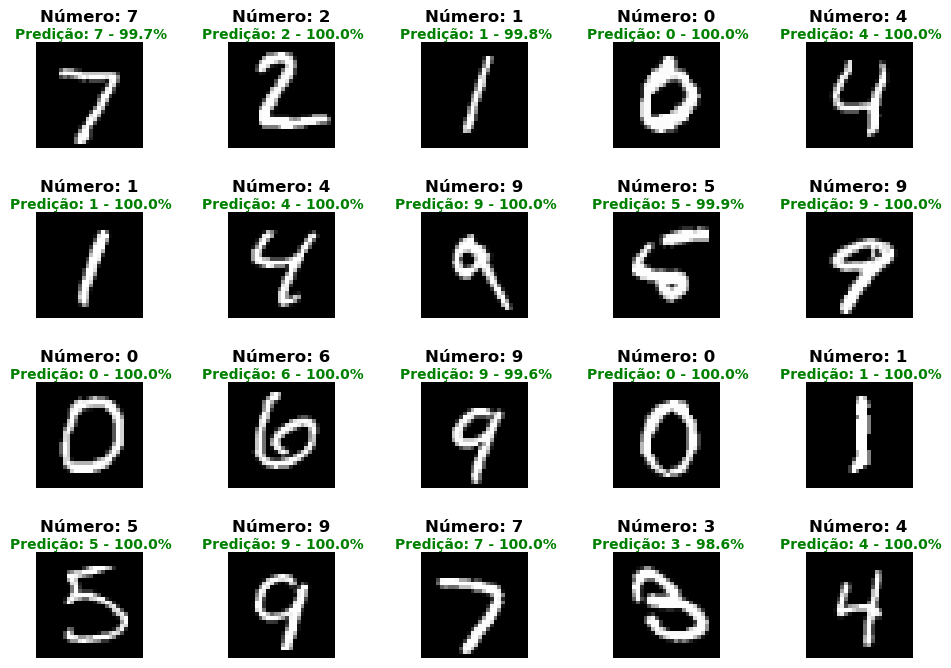

In [52]:
fig, axs = plt.subplots(4, 5, figsize=(12, 8))

for i, ax in enumerate(axs.flat):
    ax.imshow(x_test[i], cmap="gray")
    ax.set_title(f"Número: {y_test[i]}", pad=15, fontweight="bold")
    ax.axis("off")
    pred = model.predict(np.expand_dims(x_test[i], axis=0), verbose=0)[0]
    ax.text(
        14,
        -2.5,
        f"Predição: {pred.argmax()} - {pred.max():.1%}",
        color="green" if pred.argmax() == y_test[i] else "red",
        fontweight="bold",
        verticalalignment="center",
        horizontalalignment="center",
    )

fig.subplots_adjust(hspace=0.6)

plt.savefig(IMAGES_DIR / "predictions_mnist.png", dpi=300, bbox_inches="tight")
plt.show()

https://www.tensorflow.org/api_docs/python/tf/keras/utils/load_img

## Predições em imagens externas

Nesta etapa, o modelo treinado é utilizado para classificar imagens armazenadas em um diretório externo.

Cada imagem é carregada, convertida para escala de cinza, redimensionada para o formato esperado pelo modelo e transformada em um tensor com dimensão:

\[
1 \times 28 \times 28
\]

Além disso, aplica-se a operação:

```python
img_array = 255 - img_array
```

Essa inversão é necessária porque a base MNIST representa os dígitos como traços claros sobre fundo escuro, enquanto muitas imagens externas podem estar no formato oposto.

Após o pré-processamento, o modelo realiza a predição e a classe com maior probabilidade é exibida na figura.

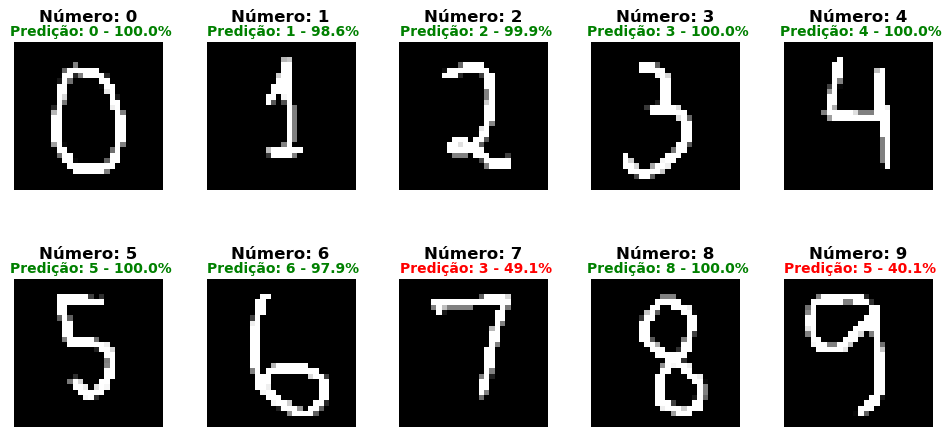

In [53]:
test_images_dir = Path("./data/test_images1")

fig, axs = plt.subplots(2, 5, figsize=(12, 5))

all_pred = {}

for i, (img, ax) in enumerate(zip(sorted(test_images_dir.glob("*.png")), axs.flat)):
    
    name = img.name.split(".")[0]
    
    img = keras.preprocessing.image.load_img(
        img, target_size=(28, 28), color_mode="grayscale"
    )
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = 255 - img_array
    img_array = tf.expand_dims(img_array, 0)
    
    pred = model.predict(img_array, verbose=0)
    all_pred[name] = pred

    ax.imshow(img_array[0], cmap="gray")
    ax.set_title(f"Número: {name}", pad=15, fontweight="bold")
    ax.axis("off")
    ax.text(
        14,
        -2.5,
        f"Predição: {pred.argmax()} - {pred.max():.1%}",
        color="green" if str(pred.argmax()) == name else "red",
        fontweight="bold",
        verticalalignment="center",
        horizontalalignment="center",
    )

fig.subplots_adjust(hspace=0.6)

plt.savefig(IMAGES_DIR / "predictions_external_base.png", dpi=300, bbox_inches="tight")
plt.show()

In [36]:
all_pred["7"]

array([[2.23750521e-05, 5.50111663e-03, 6.16837777e-02, 4.90965426e-01,
        3.51789431e-11, 1.14727634e-07, 1.04128595e-09, 4.41822737e-01,
        1.30066257e-06, 3.19056016e-06]], dtype=float32)

In [37]:
all_pred["9"]

array([[6.41049155e-06, 5.27286511e-06, 8.68066307e-03, 3.98235500e-01,
        1.52804162e-07, 4.00604218e-01, 3.11322057e-09, 1.41367263e-05,
        1.11843115e-02, 1.81269467e-01]], dtype=float32)

### Interpretação das predições

A figura apresenta as imagens avaliadas, seus rótulos esperados e as predições produzidas pelo modelo.

A maior parte das imagens foi classificada corretamente, indicando que a rede neural conseguiu generalizar bem para exemplos externos ao conjunto original de teste.

Entretanto, o modelo errou a classificação dos algarismos $\textbf{7}$ e $\textbf{9}$. Esses erros são particularmente interessantes porque mostram que, mesmo com elevada acurácia global, a rede ainda pode apresentar dificuldade em exemplos específicos.

No caso do algarismo $\textbf{7}$, o modelo atribuiu maior probabilidade à classe $\textbf{3}$:

| Classe | Probabilidade aproximada |
|---|---:|
| 3 | 49,1% |
| 7 | 44,2% |
| 2 | 6,2% |

A diferença entre as probabilidades das classes $\textbf{3}$ e $\textbf{7}$ foi pequena. Isso indica que o modelo ficou incerto entre essas duas classes. Provavelmente, a forma visual do algarismo 7 apresentado possui traços que se aproximam de um $\textbf{3}$, como curvatura, inclinação ou ausência de uma estrutura típica do número $\textbf{7}$.

No caso do algarismo $\textbf{9}$, a incerteza foi ainda mais distribuída:

| Classe | Probabilidade aproximada |
|---|---:|
| 5 | 40,1% |
| 3 | 39,8% |
| 9 | 18,1% |

Nesse exemplo, o modelo classificou o dígito como $\textbf{5}$, mas atribuiu probabilidade muito próxima à classe $\textbf{3}$ e uma probabilidade menor à classe correta $\textbf{9}$.

Esse comportamento sugere que a imagem do número 9 possui características ambíguas: possivelmente o laço superior, a haste ou o fechamento do dígito não estão suficientemente parecidos com os exemplos de 9 aprendidos durante o treinamento.

Esses erros não invalidam o modelo. Pelo contrário, eles ajudam a entender suas limitações. A análise qualitativa das classificações incorretas mostra que os erros ocorrem principalmente em imagens ambíguas ou com traços diferentes do padrão predominante da base MNIST.

# Conclusões

Neste notebook, aplicamos o Keras Tuner para automatizar a escolha de hiperparâmetros importantes da arquitetura convolucional.

A função `model_builder(hp)` permitiu definir um espaço de busca envolvendo o número de filtros das camadas convolucionais e a taxa de aprendizado do otimizador Adam.

O melhor modelo encontrado utilizou:

- 32 filtros na primeira camada convolucional;
- 64 filtros na segunda camada convolucional;
- taxa de aprendizado igual a 0.01.

Após o treinamento, o modelo alcançou **97,90% de acurácia** no conjunto de teste, demonstrando excelente capacidade de generalização.

A análise das curvas de loss e acurácia mostrou um comportamento consistente com modelos que utilizam Data Augmentation e Dropout: o treinamento é propositalmente mais difícil, enquanto a validação ocorre em condições mais estáveis.

Por fim, a análise das predições externas mostrou que, embora o modelo tenha bom desempenho global, ainda pode errar em imagens ambíguas, como observado nos algarismos 7 e 9.

Essa etapa reforça uma ideia importante em projetos de Deep Learning: além de avaliar métricas agregadas, é essencial analisar exemplos individuais para compreender melhor os acertos, os erros e as limitações do modelo.